# 🚢 YOLOv26n Training for Ship Painting Defect Detection

이 노트북은 선박 도장 결함 탐지를 위한 YOLOv26n 모델 학습을 위한 것입니다.

## Features
- 1080p 해상도 학습 (Jetson Orin Nano 웹캠에 최적화)
- MLflow 실험 추적
- TensorBoard 로깅
- 실시간 학습 모니터링

## 학습 클래스 (5종 선별)

원본 데이터셋의 11개 클래스 중 실제 선박 검사에 사용되는 5개 결함만 선별하여 학습합니다.

| YOLO ID | 영문명 | 한글명 | 원본 Category ID |
|---------|--------|--------|-----------------|
| 0 | blister | 부풀음 | 0 |
| 1 | crack | 균열 | 2 |
| 2 | peeling | 도막떨어짐 | 4 |
| 3 | sagging | 흐름 | 6 |
| 4 | welding_damage | 용접손상 | 9 |

**참고**: YOLO ID는 학습용으로 0-4로 재매핑되며, 원본 Category ID는 전체 데이터셋(11개 클래스)의 ID입니다.

## ⚠️ 학습 시작 전 체크리스트

학습 중 문제가 발생할 수 있는 흔한 원인들을 먼저 체크하세요:

### 1. 환경 진단 실행
터미널에서 다음 명령을 실행하여 환경을 체크하세요:
```bash
python src/yolo_detection/check_setup.py
```

### 2. 흔한 문제들

**문제: MLflow status:failed**
- 원인: 데이터 경로 오류, GPU 메모리 부족, 잘못된 설정값
- 해결: 아래 셀들을 순서대로 실행하면서 에러 메시지를 확인하세요

**문제: 학습이 중간에 멈춤**
- 원인 1: GPU 메모리 부족 → `BATCH_SIZE`를 4 또는 2로 줄이세요
- 원인 2: 데이터 로딩 문제 → `workers=2`로 줄이거나 `cache=False`로 변경
- 원인 3: 디스크 공간 부족 → 충분한 여유 공간 확보

**문제: CUDA out of memory**
```python
config.BATCH_SIZE = 4  # 또는 2로 줄이기
config.IMG_SIZE = 640  # 또는 더 작게
```

**문제: 데이터를 찾을 수 없음**
```bash
python src/yolo_detection/prepare_dataset.py
```

### 3. 권장 설정 (GPU 메모리별)

- **16GB+ (RTX 4080, A100 등)**: BATCH_SIZE=16, IMG_SIZE=1088
- **8-12GB (RTX 3060/3070)**: BATCH_SIZE=8, IMG_SIZE=1088 (기본값)
- **6GB (RTX 2060)**: BATCH_SIZE=4, IMG_SIZE=640
- **4GB 이하**: BATCH_SIZE=2, IMG_SIZE=480

In [20]:
import ultralytics
print(f"현재 버전: {ultralytics.__version__}") 
# 최소한 8.3.60 이상이어야 YOLO26n이 돌아감

현재 버전: 8.4.7


# Trouble Shooting
- YOLOv26n이 26년 1월 14일에 출시되었기 때문에, ultralytics 버전이 8.3.60버전 이상 이어야 돌아감.

1. yolo26n.pt 파일 삭제 후 자동 재다운로드
가장 의심되는 건 팀장님이 가지고 있는 모델 파일 자체가 정식 출시 전의 '베타' 버전일 경우야. 1월 14일 정식 출시 전후로 모델 구조가 미세하게 바뀌었을 수 있거든.

방법: 지금 폴더에 있는 yolo26n.pt 파일을 아예 삭제해 버려.

효과: 코드를 다시 실행하면 ultralytics 8.3.253 버전이 현재 버전에 딱 맞는 정식 모델 파일을 서버에서 새로 받아올 거야.

2. 로컬 ultralytics 폴더 확인 ( import 우선순위 문제)
혹시 주피터 노트북 파일(train.ipynb)이 있는 폴더에 ultralytics라는 이름의 폴더가 따로 있어?

원인: 파이썬은 pip으로 설치한 패키지보다 현재 작업 중인 폴더에 있는 소스코드를 먼저 읽어와. 만약 예전에 공부하면서 내려받아 둔 옛날 소스 폴더가 있다면, 아무리 패키지를 업데이트해도 옛날 코드가 실행되면서 에러가 나.

방법: 작업 폴더에 ultralytics 폴더가 보인다면 이름을 ultralytics_old로 바꾸거나 다른 곳으로 옮기고 다시 실행해 봐.

3. 패키지 '강제 재설치' (Force Reinstall)
단순 업데이트(-U)로 해결되지 않는 찌꺼기 파일이 있을 수 있어.

방법: 셀에서 아래 명령어를 실행해 줘.

Python
!pip uninstall -y ultralytics
!pip install --no-cache-dir ultralytics
효과: 캐시를 무시하고 최신 파일을 깨끗하게 다시 설치해.

In [1]:
# 필요한 라이브러리 import
from pathlib import Path
from datetime import datetime
import glob

class TrainingConfig:
    """학습 설정"""
    
    # 모델 설정
    MODEL_NAME = 'yolo26n.pt'  # Base model
    RESUME = None  # 이전 학습 이어하기 (None으로 설정하면 새로운 학습)
    
    # 학습 하이퍼파라미터
    EPOCHS = 40  # 보수적 학습 (early stopping 활용)
    BATCH_SIZE = 4  # GPU 메모리 절약 + 학습 속도 향상
    IMG_SIZE = 896  # 중간 해상도 (640과 1088 사이), gpu 이슈 때문에 1088은 할 수 없음
    
    # Optimizer
    OPTIMIZER = 'AdamW'
    LR0 = 0.001  # Initial learning rate
    LRF = 0.01   # Final learning rate factor
    MOMENTUM = 0.937
    WEIGHT_DECAY = 0.0005
    
    # Augmentation
    AUGMENT = True
    HSV_H = 0.015
    HSV_S = 0.7
    HSV_V = 0.4
    DEGREES = 0.0
    TRANSLATE = 0.1
    SCALE = 0.5
    SHEAR = 0.0
    PERSPECTIVE = 0.0
    FLIPUD = 0.0
    FLIPLR = 0.5
    MOSAIC = 1.0
    MIXUP = 0.0
    
    # 시각화 및 로깅
    MLFLOW_EXPERIMENT_NAME = 'ship_defect_detection'
    TENSORBOARD = True
    WANDB = False  # W&B 사용 시 True로 변경
    
    # 저장 설정
    PROJECT = 'ship_defect_yolov26n'
    
    def __init__(self, base_dir: Path = None):
        if base_dir is None:
            # 노트북의 위치를 기준으로 base_dir 설정
            base_dir = Path.cwd().parent.parent
        
        self.MODEL_PATH = base_dir / 'src' / 'yolo_detection' / 'yolo26n.pt'
        self.DATA_YAML = base_dir / 'data' / 'yolo_dataset' / 'data.yaml'
        self.PROJECT_DIR = base_dir / 'experiments' / 'yolo_runs'
        mlruns_path = base_dir / 'experiments' / 'mlruns'
        
        # Windows 경로를 MLflow URI로 변환
        self.MLFLOW_TRACKING_URI = mlruns_path.as_uri()
        
        # Run name with timestamp
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        self.NAME = f'yolov26n_896_{timestamp}'

# 설정 초기화
config = TrainingConfig()

# =====================================
# 🔄 이전 학습 이어하기 (RESUME) - 현재 비활성화
# =====================================
# 새로운 학습을 시작하려면 아래 주석을 그대로 유지하세요
# 이전 학습을 이어하려면 아래 주석을 해제하세요

# recent_runs = sorted(glob.glob(str(config.PROJECT_DIR / 'yolov26n_*')))
# if recent_runs:
#     last_checkpoint = Path(recent_runs[-1]) / 'weights' / 'last.pt'
#     if last_checkpoint.exists():
#         config.RESUME = str(last_checkpoint)
#         print(f"✅ 이전 학습 발견: {config.RESUME}")
#         print(f"   이전 학습을 이어서 진행합니다.\n")
#     else:
#         print("⚠️  최근 체크포인트(last.pt)를 찾을 수 없습니다.")
#         print("   새로운 학습을 시작합니다.\n")
# else:
#     print("ℹ️  이전 학습을 찾을 수 없습니다.")
#     print("   새로운 학습을 시작합니다.\n")

print("=" * 70)
print("Training Configuration (옵션 1: 중간 해상도 + 빠른 학습)")
print("=" * 70)
print(f"Model: {config.MODEL_NAME}")
print(f"Resume: {config.RESUME if config.RESUME else 'None (새로운 학습)'}")
print(f"Image Size: {config.IMG_SIZE} (640보다 40% 크고, 1088보다 메모리 35% 절약)")
print(f"Epochs: {config.EPOCHS}")
print(f"Batch Size: {config.BATCH_SIZE} (학습 속도 2배 향상)")
print(f"Optimizer: {config.OPTIMIZER}")
print(f"Learning Rate: {config.LR0}")
print(f"Model Path: {config.MODEL_PATH}")
print(f"Data YAML: {config.DATA_YAML}")
print(f"Output Directory: {config.PROJECT_DIR / config.NAME}")
print(f"Workers: 2")
print("=" * 70)
print("\n💡 장점:")
print("  - 작은 결함 탐지 개선 (640 대비)")
print("  - GPU 메모리 절약 (1088 대비)")
print("  - 학습 속도 2배 (batch_size=4)")
print("=" * 70)

Training Configuration (옵션 1: 중간 해상도 + 빠른 학습)
Model: yolo26n.pt
Resume: None (새로운 학습)
Image Size: 896 (640보다 40% 크고, 1088보다 메모리 35% 절약)
Epochs: 40
Batch Size: 4 (학습 속도 2배 향상)
Optimizer: AdamW
Learning Rate: 0.001
Model Path: c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\src\yolo_detection\yolo26n.pt
Data YAML: c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\data\yolo_dataset\data.yaml
Output Directory: c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs\yolov26n_896_20260127_062646
Workers: 2

💡 장점:
  - 작은 결함 탐지 개선 (640 대비)
  - GPU 메모리 절약 (1088 대비)
  - 학습 속도 2배 (batch_size=4)


## 1. 환경 설정 및 라이브러리 임포트

In [2]:
import os
import sys
import yaml
import torch
import mlflow
import mlflow.pytorch
from pathlib import Path
from datetime import datetime
from ultralytics import YOLO

# GPU 확인
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA version: 12.1


## 2. 학습 설정 (Training Configuration)

여기서 하이퍼파라미터를 조정할 수 있습니다.

## 3. MLflow 및 TensorBoard 설정

학습 과정을 추적하고 시각화하기 위한 설정입니다.

In [3]:
# 모델 로드
if config.RESUME:
    # 이전 학습 이어하기
    print(f"🔄 Resuming training from: {config.RESUME}")
    model = YOLO(str(config.RESUME))
    print("✅ Loaded checkpoint successfully!")
elif config.MODEL_PATH.exists():
    print(f"✅ Loading pretrained model: {config.MODEL_PATH}")
    model = YOLO(str(config.MODEL_PATH))
else:
    print(f"⚠️  Warning: {config.MODEL_PATH} not found")
    print("Using default yolov8n as fallback")
    model = YOLO('yolov8n.pt')

# 모델 정보 출력
print(f"\nModel Summary:")
print(model.info())

✅ Loading pretrained model: c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\src\yolo_detection\yolo26n.pt

Model Summary:
YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs
(260, 2572280, 0, 6.1192448)


## 4. 데이터 검증

학습 전에 데이터셋이 제대로 준비되었는지 확인합니다.

In [4]:
# 데이터 YAML 파일 확인
if not config.DATA_YAML.exists():
    print(f"❌ Error: Data YAML not found at {config.DATA_YAML}")
    print("\n데이터셋을 먼저 준비해야 합니다:")
    print("  python src/yolo_detection/prepare_dataset.py")
else:
    print(f"✅ Data YAML found: {config.DATA_YAML}")
    
    # YAML 내용 확인
    with open(config.DATA_YAML, 'r', encoding='utf-8') as f:
        data_config = yaml.safe_load(f)
    
    print("\n데이터셋 정보:")
    print(f"  Train: {data_config.get('train', 'N/A')}")
    print(f"  Val: {data_config.get('val', 'N/A')}")
    print(f"  Classes: {data_config.get('nc', 'N/A')}")
    print(f"  Names: {data_config.get('names', 'N/A')}")

✅ Data YAML found: c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\data\yolo_dataset\data.yaml

데이터셋 정보:
  Train: train/images
  Val: val/images
  Classes: 5
  Names: {0: 'sagging', 1: 'crack', 2: 'blister', 3: 'welding_damage', 4: 'peeling'}


In [ ]:
# 학습 시작
print("\n" + "=" * 70)
print("Starting Training...")
print("=" * 70)
print(f"Model: {config.MODEL_NAME}")
if config.RESUME:
    print(f"Resume from: {config.RESUME}")
print("=" * 70 + "\n")

# MLflow 설정 (YOLO가 자동으로 연동)
import os
os.environ['MLFLOW_TRACKING_URI'] = config.MLFLOW_TRACKING_URI
os.environ['WANDB_MODE'] = 'disabled'   # W&B 비활성화

print(f"📊 MLflow Tracking: {config.MLFLOW_TRACKING_URI}")
print(f"📊 TensorBoard: tensorboard --logdir {config.PROJECT_DIR}\n")

try:
    # 학습 실행 (YOLO가 자동으로 MLflow 연동)
    if config.RESUME:
        print(f"⚠️  Resume 모드: 이전 epoch부터 이어서 학습합니다.\n")
        results = model.train(
            resume=True,
            epochs=config.EPOCHS,
            project=str(config.PROJECT_DIR),
            name=config.NAME,
            device=0 if torch.cuda.is_available() else 'cpu',
            workers=2,
            verbose=True,
            plots=True,
        )
    else:
        # 새로운 학습
        results = model.train(
            data=str(config.DATA_YAML),
            epochs=config.EPOCHS,
            batch=config.BATCH_SIZE,
            imgsz=config.IMG_SIZE,
            
            # Optimizer
            optimizer=config.OPTIMIZER,
            lr0=config.LR0,
            lrf=config.LRF,
            momentum=config.MOMENTUM,
            weight_decay=config.WEIGHT_DECAY,
            
            # Augmentation
            augment=config.AUGMENT,
            hsv_h=config.HSV_H,
            hsv_s=config.HSV_S,
            hsv_v=config.HSV_V,
            degrees=config.DEGREES,
            translate=config.TRANSLATE,
            scale=config.SCALE,
            shear=config.SHEAR,
            perspective=config.PERSPECTIVE,
            flipud=config.FLIPUD,
            fliplr=config.FLIPLR,
            mosaic=config.MOSAIC,
            mixup=config.MIXUP,
            
            # Logging & Saving
            project=str(config.PROJECT_DIR),
            name=config.NAME,
            
            # Training options
            patience=20,
            save=True,
            save_period=10,
            cache=True,
            device=0 if torch.cuda.is_available() else 'cpu',
            workers=2,
            verbose=True,
            plots=True,
        )
    
    print("\n" + "=" * 70)
    print("Training Completed!")
    print("=" * 70)
    print(f"Results saved to: {config.PROJECT_DIR / config.NAME}")
    print("=" * 70)
    print("\n📊 학습 결과 확인:")
    print(f"   MLflow UI: mlflow ui --backend-store-uri {config.MLFLOW_TRACKING_URI}")
    print(f"   TensorBoard: tensorboard --logdir {config.PROJECT_DIR}")
    
except KeyboardInterrupt:
    print("\n\n⚠️  학습이 사용자에 의해 중단되었습니다.")
    raise
    
except Exception as e:
    print(f"\n\n❌ 학습 중 에러 발생: {e}")
    print(f"에러 타입: {type(e).__name__}")
    
    import traceback
    print("\n전체 에러 스택:")
    print(traceback.format_exc())
    
    raise


Starting Training...
Model: yolo26n.pt

📊 MLflow Tracking: file:///c:/Users/SSAFY/Desktop/S14P11E201/AI/kyr/experiments/mlruns
📊 TensorBoard: tensorboard --logdir c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs

Ultralytics 8.4.7  Python-3.10.19 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\data\yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, 

c:\Users\SSAFY\miniforge3\envs\safedeck\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/01/27 06:29:40 INFO mlflow.tracking.fluent: Experiment with name 'c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs' does not exist. Creating a new experiment.


MLflow: logging run_id(d81ab6941d164f7ea65749345fa528b2) to file:///c:/Users/SSAFY/Desktop/S14P11E201/AI/kyr/experiments/mlruns
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 896 train, 896 val
Using 2 dataloader workers
Logging results to C:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs\yolov26n_896_20260127_062646
Starting training for 40 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/40      1.23G      1.338      2.067    0.01787         11        896: 100% ━━━━━━━━━━━━ 1162/1162 2.4it/s 7:56<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 146/146 3.7it/s 39.8s0.3ss
                   all       1162       1338      0.563      0.589      0.598       0.42

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/40      1.38G      1.199      1.275    0.01593         10        896: 100% ━━━━━━━━━━━━ 1162/1162 2.3i

## 6. 학습 시작

이제 학습을 시작합니다. YOLO는 자동으로 TensorBoard 로그를 생성합니다.

### 실시간 모니터링 방법:

**터미널 1: TensorBoard**
```bash
tensorboard --logdir experiments/yolo_runs
```
브라우저에서: http://localhost:6006

**터미널 2: MLflow UI**
```bash
mlflow ui --backend-store-uri file:///c:/Users/SSAFY/Desktop/S14P11E201/AI/kyr/experiments/mlruns
```
브라우저에서: http://localhost:5000

**또는 통합 대시보드:**
```bash
python src/yolo_detection/visualization_dashboard.py --launch
```

## 7. 학습 결과 분석

학습 곡선 (Training Curves):


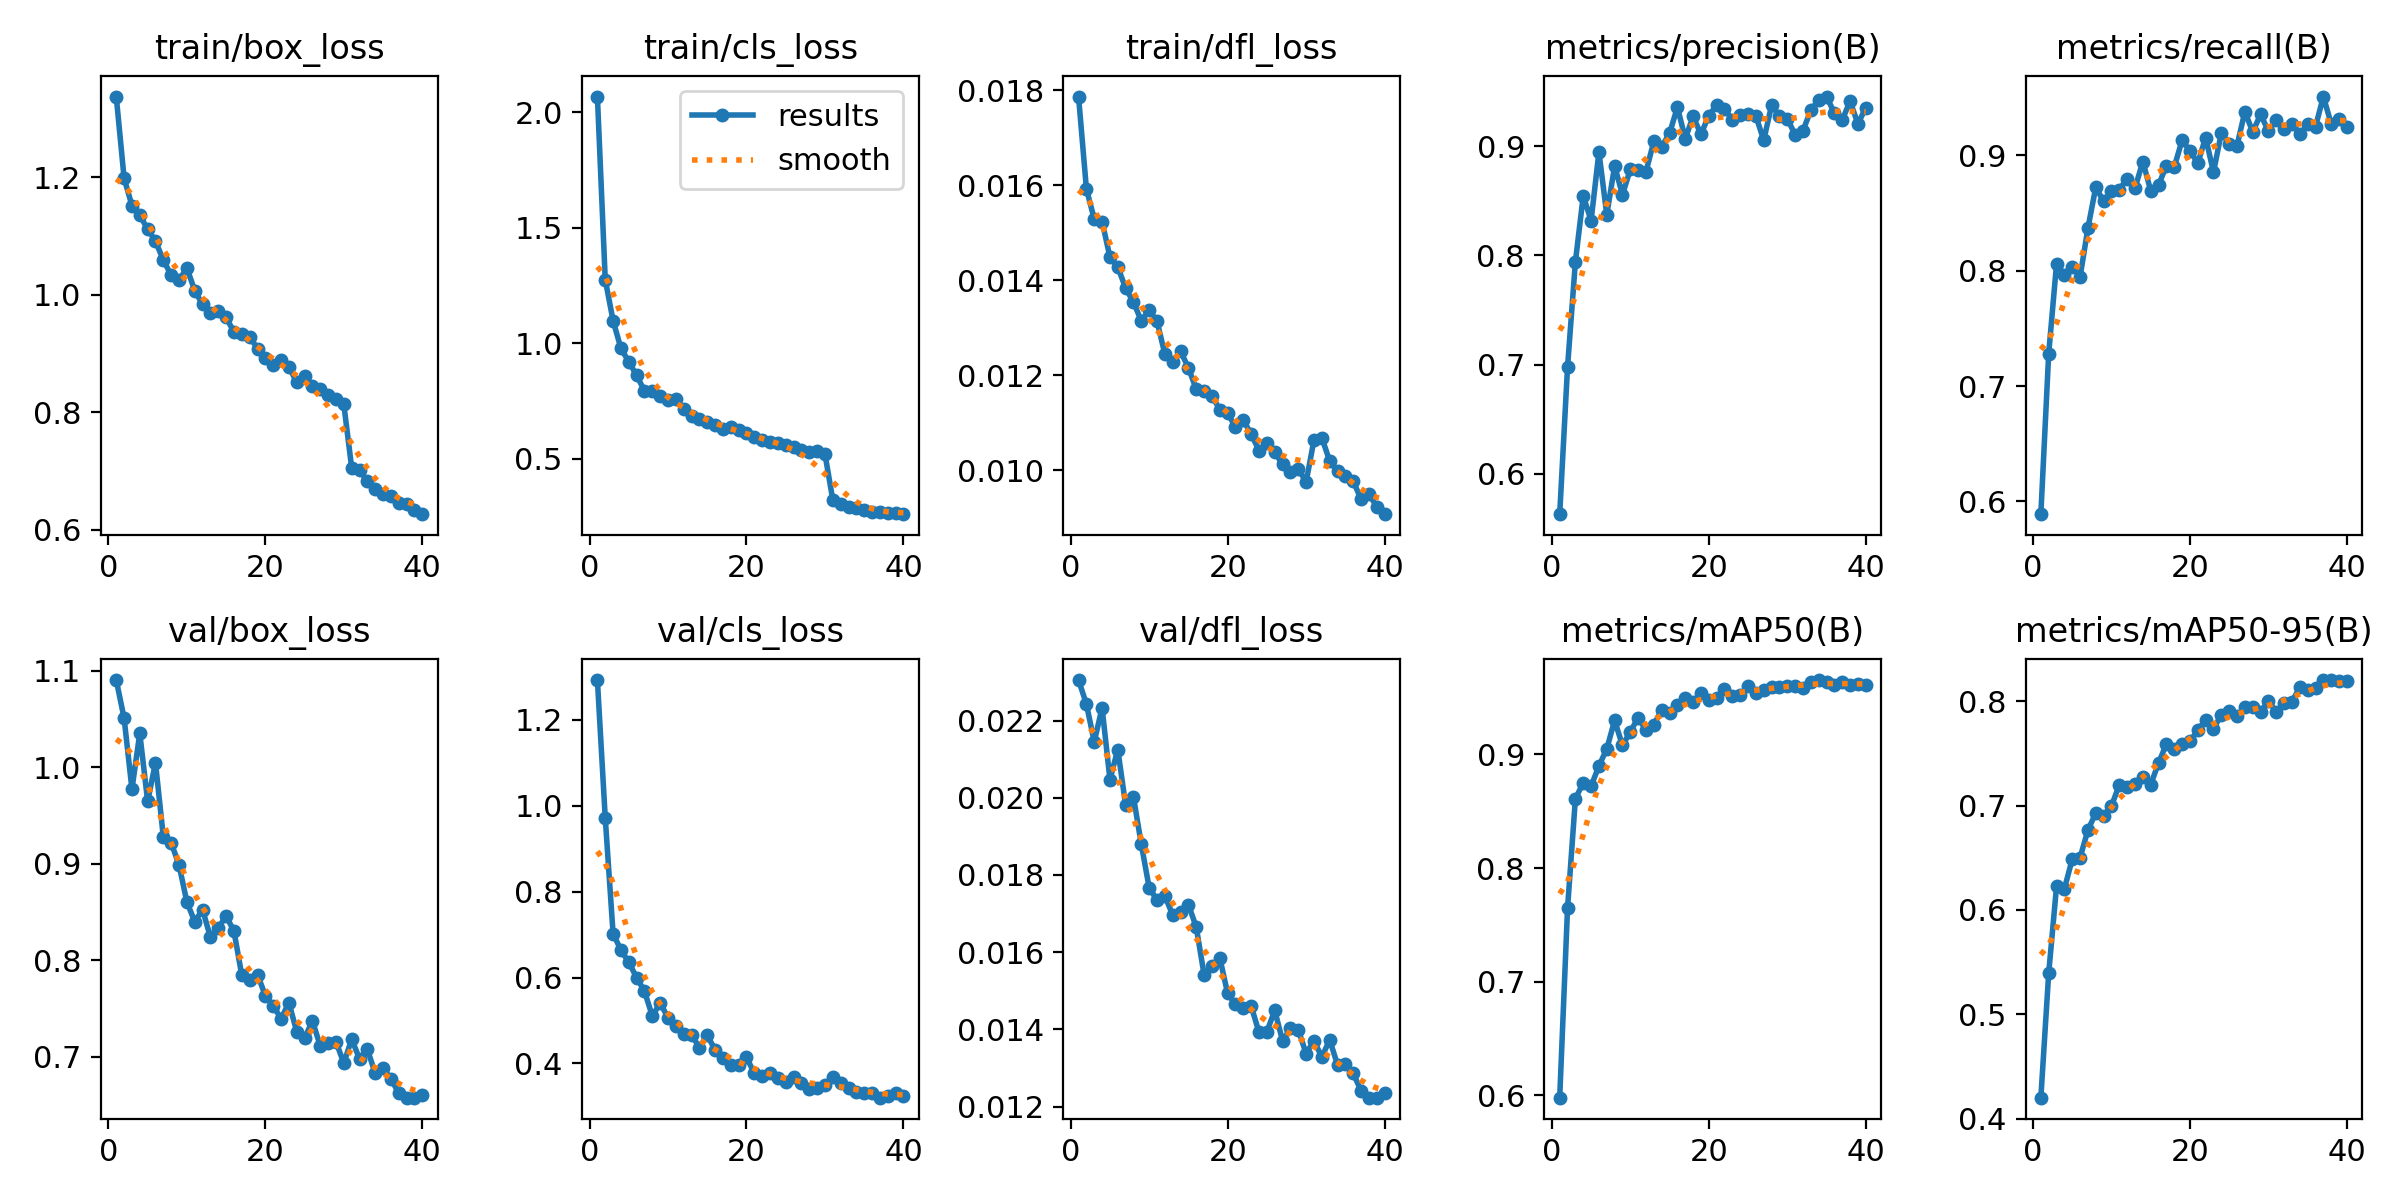


Confusion Matrix:


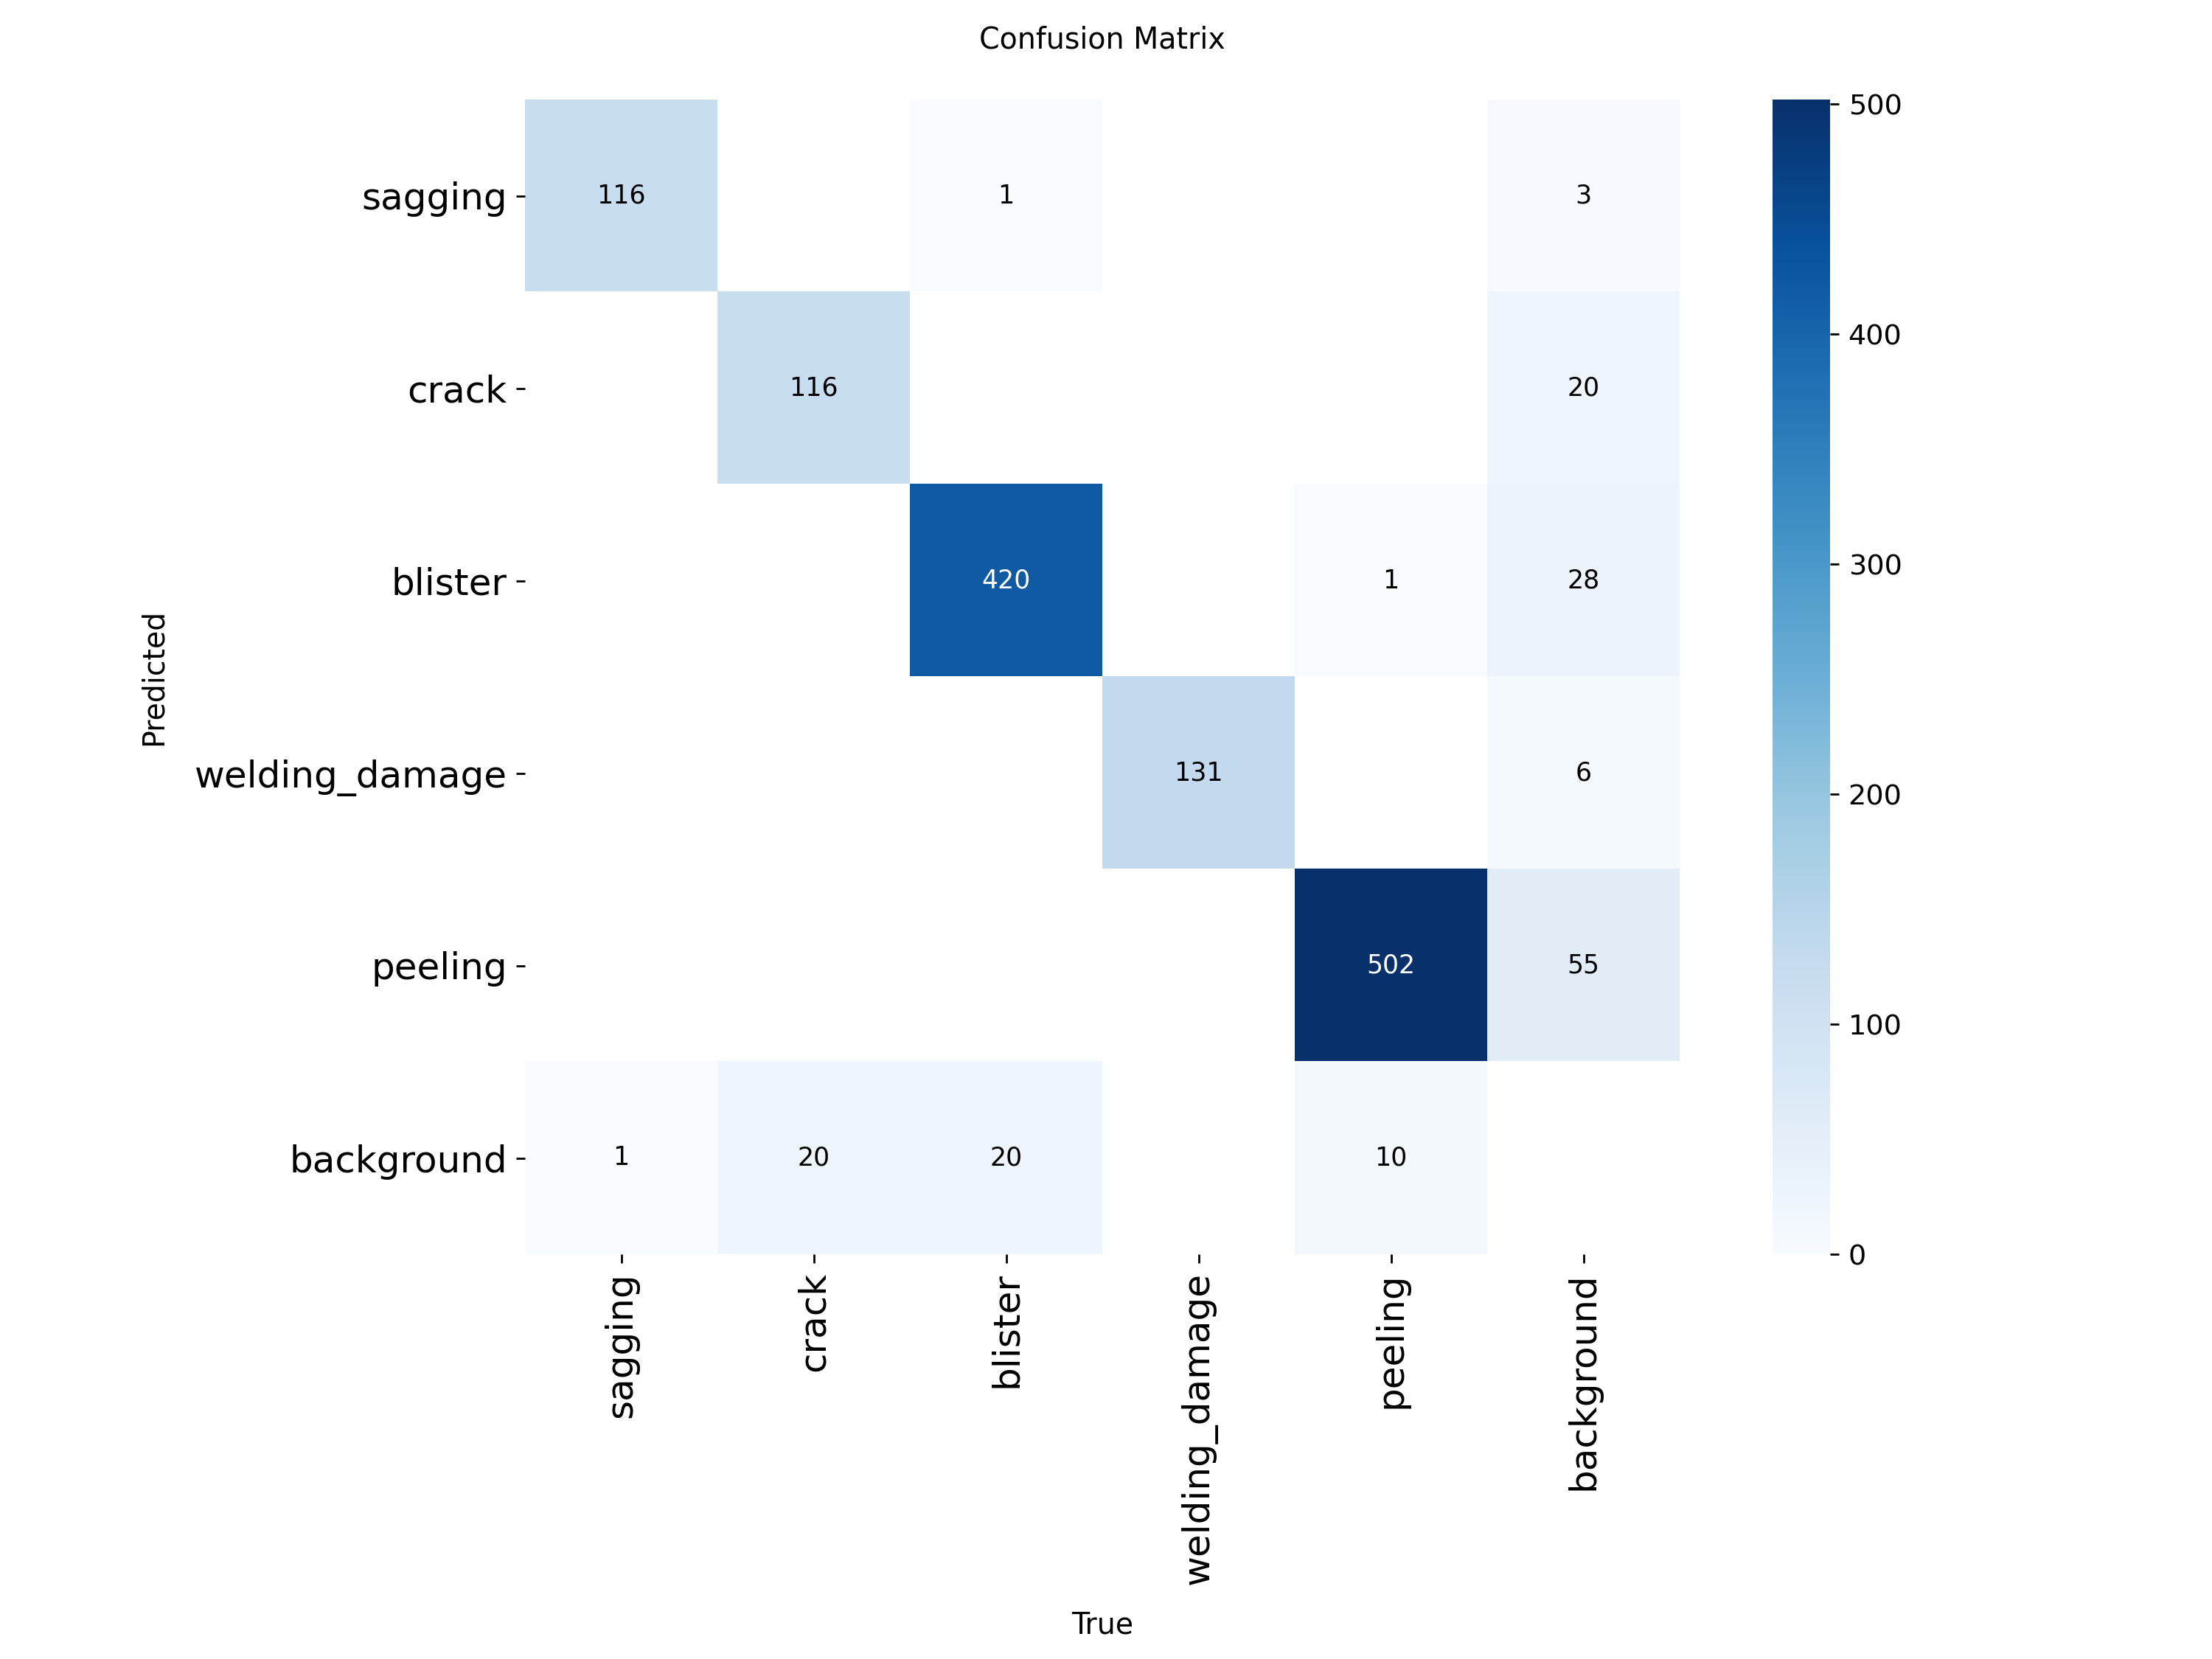


학습 통계 (마지막 5 에폭):
    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
35     36  10767.9         0.65681         0.26945         0.00978   
36     37  11063.4         0.64595         0.26814         0.00939   
37     38  11357.7         0.64477         0.26411         0.00950   
38     39  11660.7         0.63457         0.26451         0.00924   
39     40  11953.3         0.62669         0.26044         0.00908   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
35               0.93060            0.92495           0.96085   
36               0.92395            0.95103           0.96404   
37               0.94143            0.92728           0.96068   
38               0.92064            0.93154           0.96219   
39               0.93521            0.92424           0.96141   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
35              0.81319       0.67752       0.33204       0.01286  0.000134   
36         

In [6]:
from IPython.display import Image, display
import pandas as pd

results_dir = config.PROJECT_DIR / config.NAME

# 학습 곡선 시각화
results_plot = results_dir / 'results.png'
if results_plot.exists():
    print("학습 곡선 (Training Curves):")
    display(Image(filename=str(results_plot)))

# Confusion Matrix
confusion_matrix = results_dir / 'confusion_matrix.png'
if confusion_matrix.exists():
    print("\nConfusion Matrix:")
    display(Image(filename=str(confusion_matrix)))

# CSV 결과 읽기
results_csv = results_dir / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # 공백 제거
    print("\n학습 통계 (마지막 5 에폭):")
    print(df.tail())

## 8. 모델 검증 (Validation)

In [ ]:
# Best model로 검증 (수정된 모델 사용)
best_model_path = config.PROJECT_DIR / config.NAME / 'weights' / 'best.pt'
fixed_model_path = best_model_path.parent / 'best_fixed.pt'

# best_fixed.pt가 있으면 사용, 없으면 best.pt 사용
if fixed_model_path.exists():
    print(f"Loading fixed model: {fixed_model_path}")
    best_model = YOLO(str(fixed_model_path))
elif best_model_path.exists():
    print(f"Loading best model: {best_model_path}")
    best_model = YOLO(str(best_model_path))
else:
    print(f"Best model not found at {best_model_path}")
    best_model = None

if best_model:
    # 검증 실행
    val_results = best_model.val(data=str(config.DATA_YAML))
    
    print("\n" + "=" * 70)
    print("Validation Results")
    print("=" * 70)
    print(f"mAP50: {val_results.box.map50:.4f}")
    print(f"mAP50-95: {val_results.box.map:.4f}")
    print(f"Precision: {val_results.box.mp:.4f}")
    print(f"Recall: {val_results.box.mr:.4f}")
    print("=" * 70)
    
    # 클래스별 성능 (원본 카테고리 ID 포함)
    class_info = [
        ('blister', '부풀음', 0),
        ('crack', '균열', 2),
        ('peeling', '도막떨어짐', 4),
        ('sagging', '흐름', 6),
        ('welding_damage', '용접손상', 9)
    ]
    
    print("\n클래스별 AP50:")
    print(f"{'YOLO ID':<10} {'영문명':<20} {'한글명':<15} {'원본 ID':<10} {'AP50':<10}")
    print("-" * 70)
    for i, ((name_en, name_kr, orig_id), ap) in enumerate(zip(class_info, val_results.box.ap50)):
        print(f"{i:<10} {name_en:<20} {name_kr:<15} {orig_id:<10} {ap:.4f}")

## 9. 테스트 추론 (Sample Predictions)

검증 이미지로 테스트 추론을 실행합니다.

In [19]:
import torch

# 올바른 클래스 이름 매핑
CORRECT_NAMES = {
    0: 'blister',
    1: 'crack',
    2: 'peeling',
    3: 'sagging',
    4: 'welding_damage'
}

# 모델 파일 경로
model_path = config.PROJECT_DIR / config.NAME / 'weights' / 'best.pt'
fixed_model_path = model_path.parent / 'best_fixed.pt'

# best_fixed.pt가 없으면 생성
if not fixed_model_path.exists():
    print("=" * 70)
    print("모델 파일 names 수정")
    print("=" * 70)

    # 모델 가중치 로드
    checkpoint = torch.load(str(model_path), map_location='cpu', weights_only=False)

    # 현재 저장된 names 확인
    print(f"수정 전 names: {checkpoint['model'].names}")

    # 올바른 names로 수정
    checkpoint['model'].names = CORRECT_NAMES

    # 수정된 모델 저장
    torch.save(checkpoint, str(fixed_model_path))
    print(f"수정 후 names: {checkpoint['model'].names}")
    print(f"\n✅ 수정된 모델 저장: {fixed_model_path}")
else:
    print(f"✅ 수정된 모델 사용: {fixed_model_path}")

# 수정된 모델로 다시 로드
print("\n" + "=" * 70)
print("수정된 모델로 모든 클래스 추론 테스트")
print("=" * 70)

best_model = YOLO(str(fixed_model_path))
print(f"로드된 모델 names: {best_model.names}")

# 모든 클래스별로 테스트 이미지 선택
val_images_dir = config.DATA_YAML.parent / 'val' / 'images'
class_prefixes = ['blister', 'crack', 'peeling', 'sagging', 'welding_damage']

print(f"\n각 클래스별 1개씩 총 5개 이미지 추론 테스트\n")
print("-" * 70)

all_correct = True
for class_name in class_prefixes:
    # 해당 클래스 이미지 1개 선택
    class_images = list(val_images_dir.glob(f'{class_name}*.jpg'))
    
    if class_images:
        img_path = class_images[0]
        results = best_model.predict(
            source=str(img_path),
            save=True,
            project=str(results_dir / 'predictions'),
            name='all_classes_test',
            conf=0.25,
            verbose=False
        )
        
        if results[0].boxes:
            detections = []
            for box in results[0].boxes:
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                pred_name = results[0].names[class_id]
                detections.append(f"{pred_name}({confidence:.2f})")
            
            # 파일명의 클래스와 예측 클래스 비교
            pred_class = results[0].names[int(results[0].boxes[0].cls[0])]
            match = "✅" if pred_class == class_name else "❌"
            if pred_class != class_name:
                all_correct = False
            
            print(f"{match} {class_name:20} → 예측: {', '.join(detections)}")
        else:
            print(f"⚠️  {class_name:20} → 탐지 없음")
            all_correct = False
    else:
        print(f"⚠️  {class_name} 이미지를 찾을 수 없습니다.")

print("-" * 70)
if all_correct:
    print("\n🎉 모든 클래스가 올바르게 인식됩니다!")
else:
    print("\n⚠️  일부 클래스가 올바르게 인식되지 않았습니다.")

print(f"\n예측 결과 저장 위치: {results_dir / 'predictions' / 'all_classes_test'}")

✅ 수정된 모델 사용: c:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs\yolov26n_896_20260127_062646\weights\best_fixed.pt

수정된 모델로 모든 클래스 추론 테스트
로드된 모델 names: {0: 'blister', 1: 'crack', 2: 'peeling', 3: 'sagging', 4: 'welding_damage'}

각 클래스별 1개씩 총 5개 이미지 추론 테스트

----------------------------------------------------------------------
Results saved to C:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs\yolov26n_896_20260127_062646\predictions\all_classes_test
✅ blister              → 예측: blister(0.88)
Results saved to C:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs\yolov26n_896_20260127_062646\predictions\all_classes_test2
✅ crack                → 예측: crack(0.71)
Results saved to C:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs\yolov26n_896_20260127_062646\predictions\all_classes_test3
✅ peeling              → 예측: peeling(0.91)
Results saved to C:\Users\SSAFY\Desktop\S14P11E201\AI\kyr\experiments\yolo_runs\yolov26n_896_20260127_062646\predicti

## 10. 다음 단계

### TensorRT 변환 (Jetson 배포용)

**중요**: 반드시 `best_fixed.pt`를 사용하세요! (올바른 클래스 이름이 포함된 모델)

```bash
python src/yolo_detection/export_tensorrt.py --model experiments/yolo_runs/{run_name}/weights/best_fixed.pt
```

### MLflow에서 실험 비교

```bash
mlflow ui --backend-store-uri file:///c:/Users/SSAFY/Desktop/S14P11E201/AI/kyr/experiments/mlruns
```

브라우저에서 http://localhost:5000 을 열어 여러 실험을 비교할 수 있습니다.

### 모델 파일 정보

- `best.pt`: 원본 학습 모델 (잘못된 클래스 이름 포함)
- `best_fixed.pt`: **수정된 모델 (올바른 클래스 이름 포함)** ← 이 파일 사용!

# Jetson Orin Nano에서 rt로 전환하는 방법
PC에서 변환하는 것보다, Orin Nano에서 바로 전환하는 것이 낫습니다. 그 이유는, 
PC에서 만든 .engine 파일은 Jetson에서 실행이 안되기도 하고, TensorRT 엔진(.engine)은 변환한 장치에서만 실행 가능합니다.

PC 에서 전환을 하려고 해도, onnx로 변환하고, ONNX 파일을 Jetson으로 복사하여 Jetson에서 TensorRT로 변환하는 방법이 있습니다.

## PC에서 ONNX만 변환
```bash
python src/yolo_detection/export_tensorrt.py --model experiments/yolo_runs/{run_name}/weights/best_fixed.pt --onnx-only
```
- ONNX 파일을 Jetson으로 복사:

scp best_fixed.onnx jetson@192.168.x.x:/home/jetson/models/
Jetson에서 TensorRT 변환:
```bash
# Jetson에서 실행
yolo export model=best_fixed.onnx format=engine half=True
```

또는 Ultralytics로 직접 Jetson에서 변환하는 방법이 있습니다.
## Ultralytics로 직접:
```python
from ultralytics import YOLO
model = YOLO('best_fixed.onnx')
model.export(format='engine', half=True)  # FP16
```
이렇게 하면 Jetson에 최적화된 TensorRT 엔진이 생성됩니다.

## 💡 백엔드 전송을 위한 ID 변환

**중요**: YOLO 모델은 0-4의 ID를 반환하지만, 백엔드에는 **원본 Category ID (0, 2, 4, 6, 9)**를 전송해야 합니다.

`__init__.py`에 있는 유틸리티 함수를 사용하여 변환할 수 있습니다.

In [9]:
# ID 변환 유틸리티 함수 임포트
import sys
from pathlib import Path

# 프로젝트 루트를 sys.path에 추가
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.yolo_detection import (
    yolo_id_to_original_id, 
    original_id_to_yolo_id, 
    get_class_info,
    ORIGINAL_CATEGORY_MAPPING
)

print("=" * 70)
print("ID 변환 매핑 테이블")
print("=" * 70)
print(f"{'YOLO ID':<12} {'원본 Category ID':<20} {'클래스명':<20} {'한글명':<15}")
print("-" * 70)

for yolo_id in range(5):
    info = get_class_info(yolo_id)
    if info:
        print(f"{info['yolo_id']:<12} {info['original_id']:<20} {info['name_en']:<20} {info['name_kr']:<15}")

print("=" * 70)
print("\n변환 예시:")
print(f"  YOLO ID 1 → 원본 ID {yolo_id_to_original_id(1)} (crack)")
print(f"  YOLO ID 4 → 원본 ID {yolo_id_to_original_id(4)} (welding_damage)")
print(f"  원본 ID 2 → YOLO ID {original_id_to_yolo_id(2)} (crack)")
print(f"  원본 ID 9 → YOLO ID {original_id_to_yolo_id(9)} (welding_damage)")

ID 변환 매핑 테이블
YOLO ID      원본 Category ID       클래스명                 한글명            
----------------------------------------------------------------------
0            0                    blister              부풀음            
1            2                    crack                균열             
2            4                    peeling              도막떨어짐          
3            6                    sagging              흐름             
4            9                    welding_damage       용접손상           

변환 예시:
  YOLO ID 1 → 원본 ID 2 (crack)
  YOLO ID 4 → 원본 ID 9 (welding_damage)
  원본 ID 2 → YOLO ID 1 (crack)
  원본 ID 9 → YOLO ID 4 (welding_damage)
